# Time Series Classification with Pirate Pain X_train_df


This notebook provides a simple, bare-bones example of how to classify time series data from the Pirate Pain dataset.


## ⚙️ Libraries Import


In [16]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check if MPS is available and set it as the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Metal) backend!")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU.")

# When you create your model and tensors, move them to the device


Using device: cpu
Using MPS (Apple Metal) backend!


## ⏳ Data Loading


In [17]:
X_test_df = pd.read_csv('data/pirate_pain_train.csv')
y_train_df = pd.read_csv('data/pirate_pain_train_labels.csv')
X_test_df = pd.read_csv('data/pirate_pain_test.csv')

print("Train data shape:", X_test_df.shape)
print("Train labels shape:", y_train_df.shape)
print("Test data shape:", X_test_df.shape)

# Convert int64, float64 to int32, float32
mapping = {
    "one+peg_leg": 1,
    "one+hook_hand": 1,
    "one+eye_patch": 1,
    "two": 2,
}

for col in X_train_df:
    if X_train_df[col].dtype == 'int64':
        X_train_df[col] = X_train_df[col].astype(np.float32)
    elif X_train_df[col].dtype == 'float64':
        X_train_df[col] = X_train_df[col].astype(np.float32)
    elif X_train_df[col].dtype == 'object':
        X_train_df[col] = X_train_df[col].replace(mapping)
        X_train_df[col] = X_train_df[col].astype(np.float32)

for col in X_test_df:
    if X_test_df[col].dtype == 'int64':
        X_test_df[col] = X_test_df[col].astype(np.float32)
    elif X_test_df[col].dtype == 'float64':
        X_test_df[col] = X_test_df[col].astype(np.float32)
    elif X_test_df[col].dtype == 'object':
        X_test_df[col] = X_test_df[col].replace(mapping)
        X_test_df[col] = X_test_df[col].astype(np.float32)


X_train_df.info()
X_train_df.head(10)
X_train_df.describe()


Train data shape: (211840, 40)
Train labels shape: (661, 2)
Test data shape: (211840, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  float32
 7   n_hands        105760 non-null  float32
 8   n_eyes         105760 non-null  float32
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-nul

/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_11561/4009331266.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_df[col] = X_test_df[col].replace(mapping)
/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_11561/4009331266.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_df[col] = X_test_df[col].replace(mapping)
/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_11561/4009331266.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future ve

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.00000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.50000,1.633746,1.654851,1.653640,1.663134,1.990923,1.990923,1.990923,0.943095,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814941,46.18734,0.682423,0.669639,0.666649,0.661994,0.094841,0.094841,0.094841,0.202051,...,4.974496e-03,5.472244e-03,1.235449e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.75000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.828277,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.50000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.005126,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746148e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.25000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.081039,...,2.800090e-06,3.079464e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.407968,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


## 🔄 Data Preprocessing


In [18]:
# Merge features and labels
train_df = pd.merge(X_train_df, y_train_df, on='sample_index')

features = train_df.columns.drop(['sample_index', 'label'])

# Label Encoding
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['label'])

# Group by sample_index and create sequences
sequences = [group[features].values for name, group in train_df.groupby('sample_index')]
labels = [group['label'].values[0] for name, group in train_df.groupby('sample_index')]
# Padding not necessary - all sequences have the same length

# Convert to numpy arrays
labels = np.array(labels)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(sequences, labels, test_size=0.2, random_state=SEED, stratify=labels)

# Convert lists to arrays (num_samples, seq_len, num_features)
X_train = np.stack(X_train)
X_val = np.stack(X_val)

# Scaling features (no padding case)
# Reshape for scaler: (num_samples * sequence_length, num_features)
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler = StandardScaler().fit(X_train_reshaped)
X_train = scaler.transform(X_train_reshaped).reshape(X_train.shape)

X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val = scaler.transform(X_val_reshaped).reshape(X_val.shape)

# Create PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)



X_train shape: (528, 160, 39)
y_train shape: (528,)
X_val shape: (133, 160, 39)
y_val shape: (133,)


## 🛠️ Model Building


In [19]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Set initial hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate GRU
        out, _ = self.gru(x, h0)

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Hyperparameters
INPUT_SIZE = X_train.shape[-1]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = len(label_encoder.classes_)

model = SimpleRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
print(model)


SimpleRNN(
  (gru): GRU(39, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


## 🧠 Model Training


In [20]:
# Loss and optimizer
LEARNING_RATE = 0.001
EPOCHS = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for sequences_batch, labels_batch in train_loader:
        sequences_batch, labels_batch = sequences_batch.to(device), labels_batch.to(device)

        # Forward pass
        outputs = model(sequences_batch)
        loss = criterion(outputs, labels_batch)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * sequences_batch.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels_batch.size(0)
        correct_train += (predicted == labels_batch).sum().item()

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for sequences_batch, labels_batch in val_loader:
            sequences_batch, labels_batch = sequences_batch.to(device), labels_batch.to(device)
            outputs = model(sequences_batch)
            loss = criterion(outputs, labels_batch)
            val_loss += loss.item() * sequences_batch.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels_batch.size(0)
            correct_val += (predicted == labels_batch).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')


Epoch [1/20], Train Loss: 0.8149, Train Acc: 0.7159, Val Loss: 0.5393, Val Acc: 0.8045
Epoch [2/20], Train Loss: 0.6044, Train Acc: 0.7955, Val Loss: 0.4975, Val Acc: 0.8120
Epoch [3/20], Train Loss: 0.5676, Train Acc: 0.7992, Val Loss: 0.4994, Val Acc: 0.8195
Epoch [4/20], Train Loss: 0.5225, Train Acc: 0.8087, Val Loss: 0.4488, Val Acc: 0.8346
Epoch [5/20], Train Loss: 0.4696, Train Acc: 0.8182, Val Loss: 0.4374, Val Acc: 0.8421
Epoch [6/20], Train Loss: 0.4174, Train Acc: 0.8371, Val Loss: 0.4124, Val Acc: 0.8421
Epoch [7/20], Train Loss: 0.3376, Train Acc: 0.8769, Val Loss: 0.3500, Val Acc: 0.8722
Epoch [8/20], Train Loss: 0.3050, Train Acc: 0.8996, Val Loss: 0.3319, Val Acc: 0.8722
Epoch [9/20], Train Loss: 0.2722, Train Acc: 0.9072, Val Loss: 0.3327, Val Acc: 0.8647
Epoch [10/20], Train Loss: 0.2336, Train Acc: 0.9223, Val Loss: 0.3284, Val Acc: 0.8797
Epoch [11/20], Train Loss: 0.2101, Train Acc: 0.9280, Val Loss: 0.3866, Val Acc: 0.8421
Epoch [12/20], Train Loss: 0.1828, Train 

## 📈 Evaluation


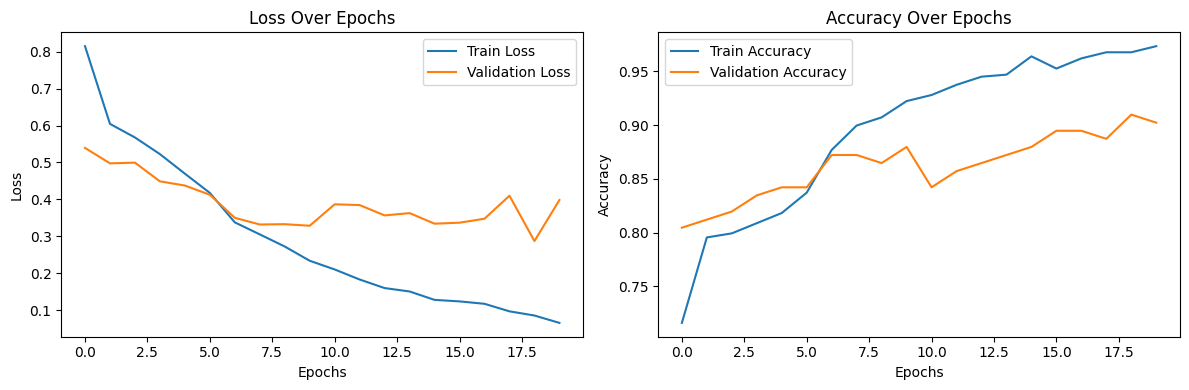

In [21]:
# Plotting training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Preprocess the test data
# Apply the same mapping as training data
for col in X_test_df:
    if X_test_df[col].dtype == 'object':
        X_test_df[col] = X_test_df[col].replace(mapping)
        X_test_df[col] = X_test_df[col].astype(np.float32)

# Group by sample_index and create sequences (without 'sample_index')
test_sequences = [group[features].values for name, group in X_test_df.groupby('sample_index')]
test_sample_indices = [name for name, group in X_test_df.groupby('sample_index')]

# Stack directly to (num_samples, seq_len, num_features)
X_test = np.stack(test_sequences)

# Scale test data with the fitted scaler
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Convert to tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# Make predictions
model.eval()
test_predictions = []
with torch.no_grad():
    for i in range(len(X_test_tensor)):
        sequence = X_test_tensor[i].unsqueeze(0)
        output = model(sequence)
        _, predicted = torch.max(output.data, 1)
        test_predictions.append(predicted.item())

# Inverse transform predictions to original labels
predicted_labels = label_encoder.inverse_transform(test_predictions)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'sample_index': test_sample_indices,
    'pain': predicted_labels
})

# Save to csv
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
submission_df.head()


KeyError: 'sample_index'